In [1]:
import pandas as pd
import numpy as np
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Everything working!")

pandas: 3.0.5
numpy: 2.5.2
Everything working!


In [2]:
import os

data_path = '../data/'
files = os.listdir(data_path)
print("Files in data folder:")
for f in files:
    size = os.path.getsize(data_path + f) / (1024**3)
    print(f"  {f} — {size:.2f} GB")

Files in data folder:
  accepted_2007_to_2018Q4.csv.gz — 0.37 GB
  df_model.csv — 0.01 GB
  df_model_with_el.csv — 0.02 GB
  df_model_with_pricing.csv — 0.03 GB
  rejected_2007_to_2018Q4.csv.gz — 0.24 GB
  test_results.csv — 0.00 GB


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Plot setting
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [5]:
df = pd.read_csv(
    '../data/accepted_2007_to_2018Q4.csv.gz',
    # nrows=100000,
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"\nLoan Status Distribution:")
print(df['loan_status'].value_counts())

Shape: (2260701, 151)

Loan Status Distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [6]:
# Keep only resolved loans
resolved = ['Fully Paid', 'Charged Off', 'Default']
df = df[df['loan_status'].isin(resolved)].copy()

# Binary target: 1 = default, 0 = paid
df['target'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)

print(f"Dataset after filtering: {df.shape}")
print(f"\nClass Distribution:")
print(df['target'].value_counts())
print(f"\nDefault Rate: {df['target'].mean()*100:.2f}%")

Dataset after filtering: (1345350, 152)

Class Distribution:
target
0    1076751
1     268599
Name: count, dtype: int64

Default Rate: 19.96%


In [7]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [8]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_last_payment_amount', 'disbursement_method',
       'debt_settlement_flag', 'debt_settlement_flag_date',
       'settlement_status', 'settlement_date', 'settlement_amount',
       'settlement_percentage', 'settlement_term', 'target'],
      dtype='str', length=152)

In [9]:
# These columns only exist AFTER loan outcome is known
# Reference notebook proved this causes 23% AUC inflation
leakage_cols = [
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high',
    'last_fico_range_low', 'debt_settlement_flag'
]

dropped = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=dropped)

print(f"Dropped {len(dropped)} leakage columns")
print(f"Remaining shape: {df.shape}")

Dropped 16 leakage columns
Remaining shape: (1345350, 136)


In [10]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,NaN,NaN,NaN,NaN,NaN,NaN,0


In [11]:
df.isna().sum()

id                             0
member_id                1345350
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
                          ...   
settlement_date          1312068
settlement_amount        1312068
settlement_percentage    1312068
settlement_term          1312068
target                         0
Length: 136, dtype: int64

In [12]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

# Columns with significant missing
print("Top 20 columns by missing %:")
print(missing[missing['missing_count'] > 0].head(20))

# Drop columns with more than 50% missing
high_missing = missing[missing['missing_pct'] > 50].index.tolist()
df = df.drop(columns=high_missing)
print(f"\nDropped {len(high_missing)} columns with >50% missing")
print(f"Final shape: {df.shape}")

Top 20 columns by missing %:
                                            missing_count  missing_pct
member_id                                         1345350       100.00
orig_projected_additional_accrued_interest        1341589        99.72
hardship_reason                                   1339594        99.57
hardship_start_date                               1339594        99.57
hardship_payoff_balance_amount                    1339594        99.57
hardship_last_payment_amount                      1339594        99.57
payment_plan_start_date                           1339594        99.57
hardship_type                                     1339594        99.57
hardship_end_date                                 1339594        99.57
hardship_length                                   1339594        99.57
hardship_loan_status                              1339594        99.57
hardship_dpd                                      1339594        99.57
hardship_amount                                 

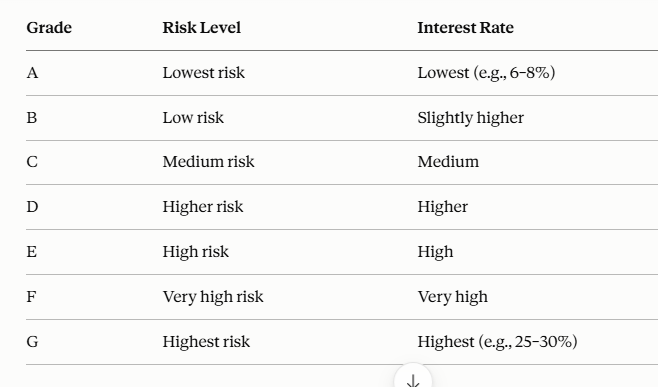

Default Rate by Loan Grade:
  grade  total_loans  defaults  default_rate_pct
0     A       235095     14206              6.04
1     B       392748     52576             13.39
2     C       381694     85657             22.44
3     D       200966     61067             30.39
4     E        93656     36041             38.48
5     F        32059     14492             45.20
6     G         9132      4560             49.93


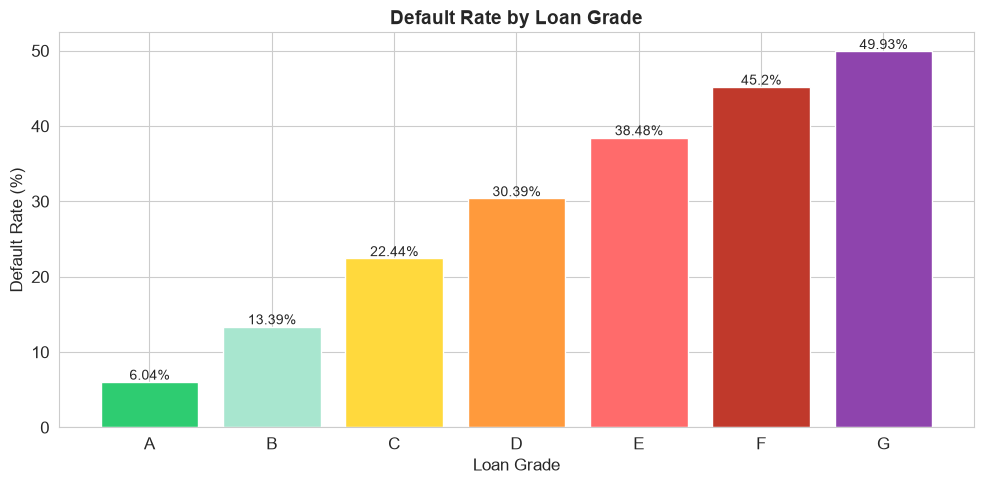

✅ Saved plot


In [13]:
grade_stats = df.groupby('grade').agg(
    total_loans=('target', 'count'),
    defaults=('target', 'sum'),
    default_rate=('target', 'mean')
).reset_index()

grade_stats['default_rate_pct'] = (grade_stats['default_rate'] * 100).round(2)

print("Default Rate by Loan Grade:")
print(grade_stats[['grade', 'total_loans', 'defaults', 'default_rate_pct']])

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(grade_stats['grade'], 
               grade_stats['default_rate_pct'],
               color=['#2ecc71','#a8e6cf','#ffd93d','#ff9a3c','#ff6b6b','#c0392b','#8e44ad'])
plt.title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
for bar, val in zip(bars, grade_stats['default_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../notebooks/images/01_default_by_grade.png', dpi=150)
plt.show()
print("✅ Saved plot")

Default Rate by Loan Purpose:
               purpose  total_loans  default_rate_pct
13             wedding         2294             12.16
0                  car        14588             14.70
1          credit_card       295285             16.93
3          educational          326             17.18
4     home_improvement        87507             17.72
6       major_purchase        29427             18.61
12            vacation         9065             19.17
9                other        77877             21.04
2   debt_consolidation       780342             21.15
7              medical        15556             21.79
5                house         7254             21.89
8               moving         9480             23.35
10    renewable_energy          933             23.69
11      small_business        15416             29.71


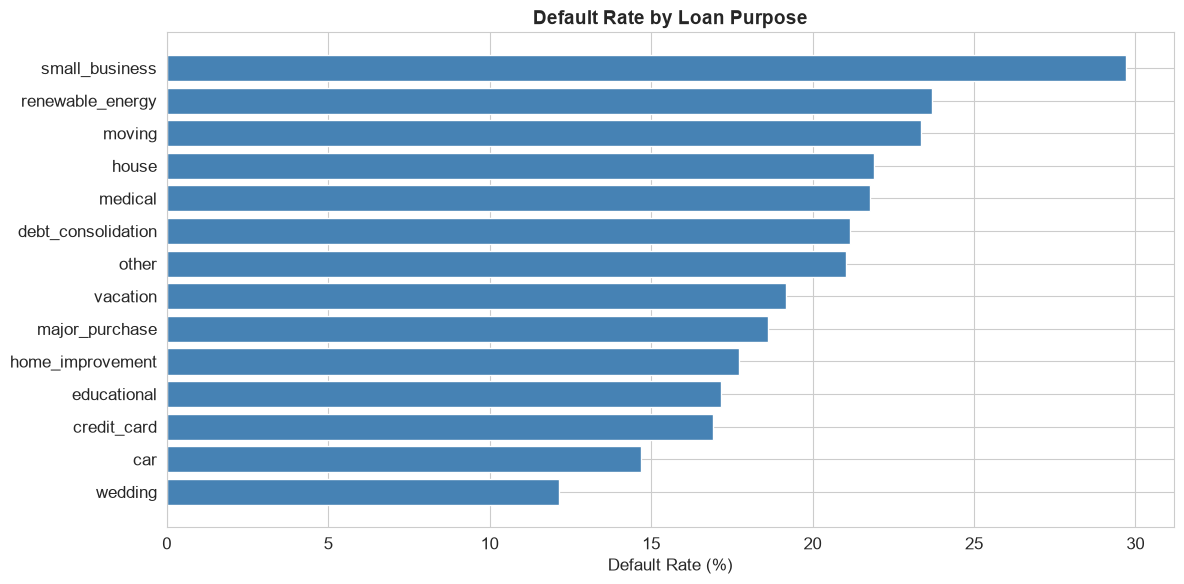

In [14]:
purpose_stats = df.groupby('purpose').agg(
    total_loans=('target', 'count'),
    default_rate=('target', 'mean')
).reset_index()

purpose_stats['default_rate_pct'] = (purpose_stats['default_rate'] * 100).round(2)
purpose_stats = purpose_stats.sort_values('default_rate_pct', ascending=True)

print("Default Rate by Loan Purpose:")
print(purpose_stats[['purpose', 'total_loans', 'default_rate_pct']])

plt.figure(figsize=(12, 6))
plt.barh(purpose_stats['purpose'], 
         purpose_stats['default_rate_pct'],
         color='steelblue')
plt.title('Default Rate by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.tight_layout()
plt.savefig('../notebooks/images/02_default_by_purpose.png', dpi=150)
plt.show()

Default Rate by DTI Bucket:
  dti_bucket  total_loans  default_rate  default_rate_pct
0       0-10       245327      0.148687             14.87
1      10-20       562128      0.178468             17.85
2      20-30       408353      0.230492             23.05
3      30-40       121541      0.291021             29.10
4      40-50         3989      0.318376             31.84


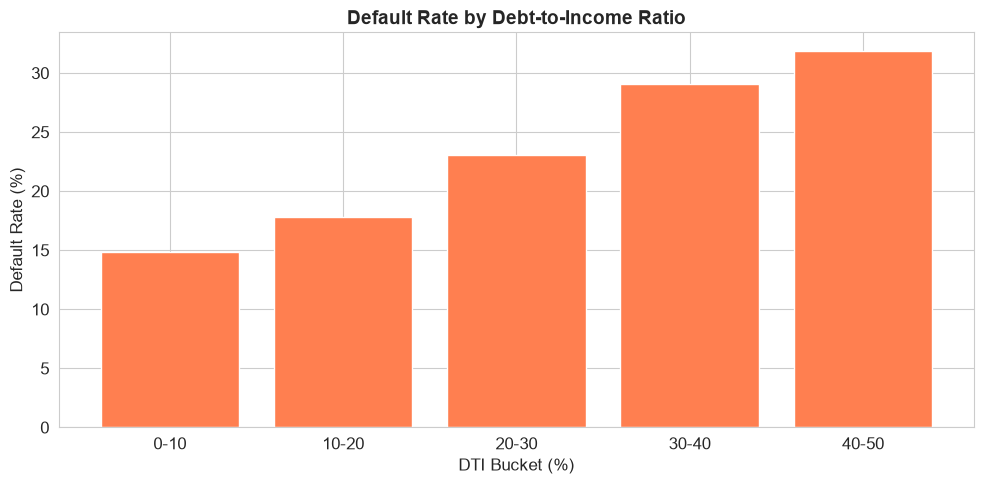

In [15]:
# DTI = Debt to Income ratio — key credit risk metric
# Remove outliers first
df_dti = df[df['dti'] < 50].copy()

# Create DTI buckets
df_dti['dti_bucket'] = pd.cut(df_dti['dti'], 
                               bins=[0, 10, 20, 30, 40, 50],
                               labels=['0-10', '10-20', '20-30', '30-40', '40-50'])

dti_stats = df_dti.groupby('dti_bucket', observed=True).agg(
    total_loans=('target', 'count'),
    default_rate=('target', 'mean')
).reset_index()

dti_stats['default_rate_pct'] = (dti_stats['default_rate'] * 100).round(2)

print("Default Rate by DTI Bucket:")
print(dti_stats)

plt.figure(figsize=(10, 5))
plt.bar(dti_stats['dti_bucket'].astype(str),
        dti_stats['default_rate_pct'],
        color='coral')
plt.title('Default Rate by Debt-to-Income Ratio', fontsize=14, fontweight='bold')
plt.xlabel('DTI Bucket (%)')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.savefig('../notebooks/images/03_default_by_dti.png', dpi=150)
plt.show()

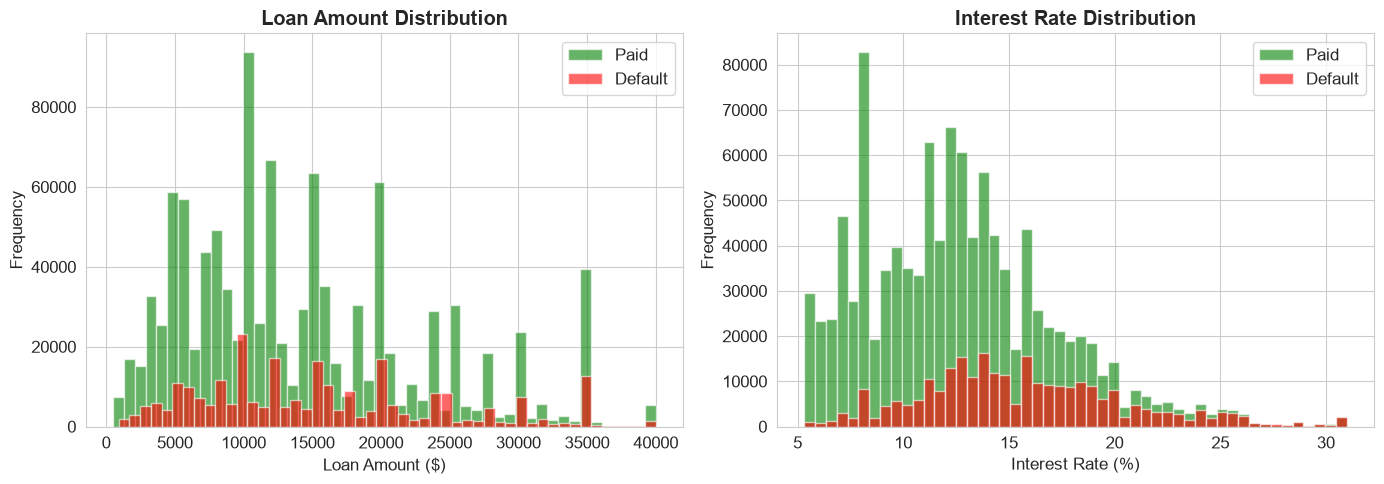

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan amount by default status
df[df['target']==0]['loan_amnt'].plot(kind='hist', bins=50, 
                                       alpha=0.6, label='Paid', 
                                       ax=axes[0], color='green')
df[df['target']==1]['loan_amnt'].plot(kind='hist', bins=50, 
                                       alpha=0.6, label='Default', 
                                       ax=axes[0], color='red')
axes[0].set_title('Loan Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].legend()

# Interest rate by default status
df[df['target']==0]['int_rate'].plot(kind='hist', bins=50,
                                      alpha=0.6, label='Paid',
                                      ax=axes[1], color='green')
df[df['target']==1]['int_rate'].plot(kind='hist', bins=50,
                                      alpha=0.6, label='Default',
                                      ax=axes[1], color='red')
axes[1].set_title('Interest Rate Distribution', fontweight='bold')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/04_distributions.png', dpi=150)
plt.show()

In [17]:
print("=" * 50)
print("KEY EDA FINDINGS")
print("=" * 50)
print(f"\n1. Dataset: {df.shape[0]:,} resolved loans, {df.shape[1]} features")
print(f"2. Overall default rate: {df['target'].mean()*100:.1f}%")
print(f"3. Grade A default rate: {df[df['grade']=='A']['target'].mean()*100:.1f}%")
print(f"4. Grade G default rate: {df[df['grade']=='G']['target'].mean()*100:.1f}%")
print(f"5. High DTI (>30) default rate: {df[df['dti']>30]['target'].mean()*100:.1f}%")
print(f"6. Low DTI (<10) default rate: {df[df['dti']<10]['target'].mean()*100:.1f}%")
print(f"\nThese findings directly inform our")
print(f"feature engineering and pricing model.")
print("=" * 50)

KEY EDA FINDINGS

1. Dataset: 1,345,350 resolved loans, 79 features
2. Overall default rate: 20.0%
3. Grade A default rate: 6.0%
4. Grade G default rate: 49.9%
5. High DTI (>30) default rate: 29.2%
6. Low DTI (<10) default rate: 14.9%

These findings directly inform our
feature engineering and pricing model.
